In [32]:
import os 
# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)

import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import matplotlib.pyplot as plt # import matplotlib to visualize our qc metrics
import subprocess
import sys
import seaborn as sns
import numpy as np

# sys.path.append('../utils')
# from functions import * 

# magic incantation to help matplotlib work with our jupyter notebook
%matplotlib inline 

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

sns.set(style="whitegrid")

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis/tabula_sapien
scanpy==1.10.1 anndata==0.10.7 umap==0.5.6 numpy==1.26.4 scipy==1.14.1 pandas==2.2.2 scikit-learn==1.4.2 statsmodels==0.14.2 igraph==0.11.5 louvain==0.8.2 pynndescent==0.5.12


In [3]:
# load adata object for tabula muris 
adata = sc.read_h5ad("/gpfs/commons/datasets/controlled/CZI/tabula-sapiens/TS_figshare/TabulaSapiens.h5ad")

In [5]:
adata

AnnData object with n_obs × n_vars = 483152 × 58870
    obs: 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender'
    var: 'gene_symbol', 'feature_type', 'ensemblid', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: '_scvi', '_training_mode', 'compartment_colors', 'dendrogram_cell_type_tissue', 'dendrogram_computational_compartment_assignment', 'dendrogram_consensus_prediction', 'dendrogram_tissue_cell_type', 'donor_colors', 'donor_method_colors', 'hvg', 'method_colors', 'neighbors', 'organ_tissue_colors', 'sex_colors', 'tissue_colors', 'umap'
    obsm: 'X_pca', 'X_scvi', 'X_scvi_umap', 'X_umap'
    layers: 'decontXcounts', 'raw_counts'
    obsp: 'connectivities', 'distances'

In [7]:
# make dataframe of counts of method by organ tissue
method_counts = adata.obs.groupby(['method', 'organ_tissue']).size().reset_index(name='counts')
method_counts.sort_values(by='counts', ascending=False, inplace=True)
order_organs = method_counts['organ_tissue'].unique()

/scratch/ipykernel_4489/811341755.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  method_counts = adata.obs.groupby(['method', 'organ_tissue']).size().reset_index(name='counts')


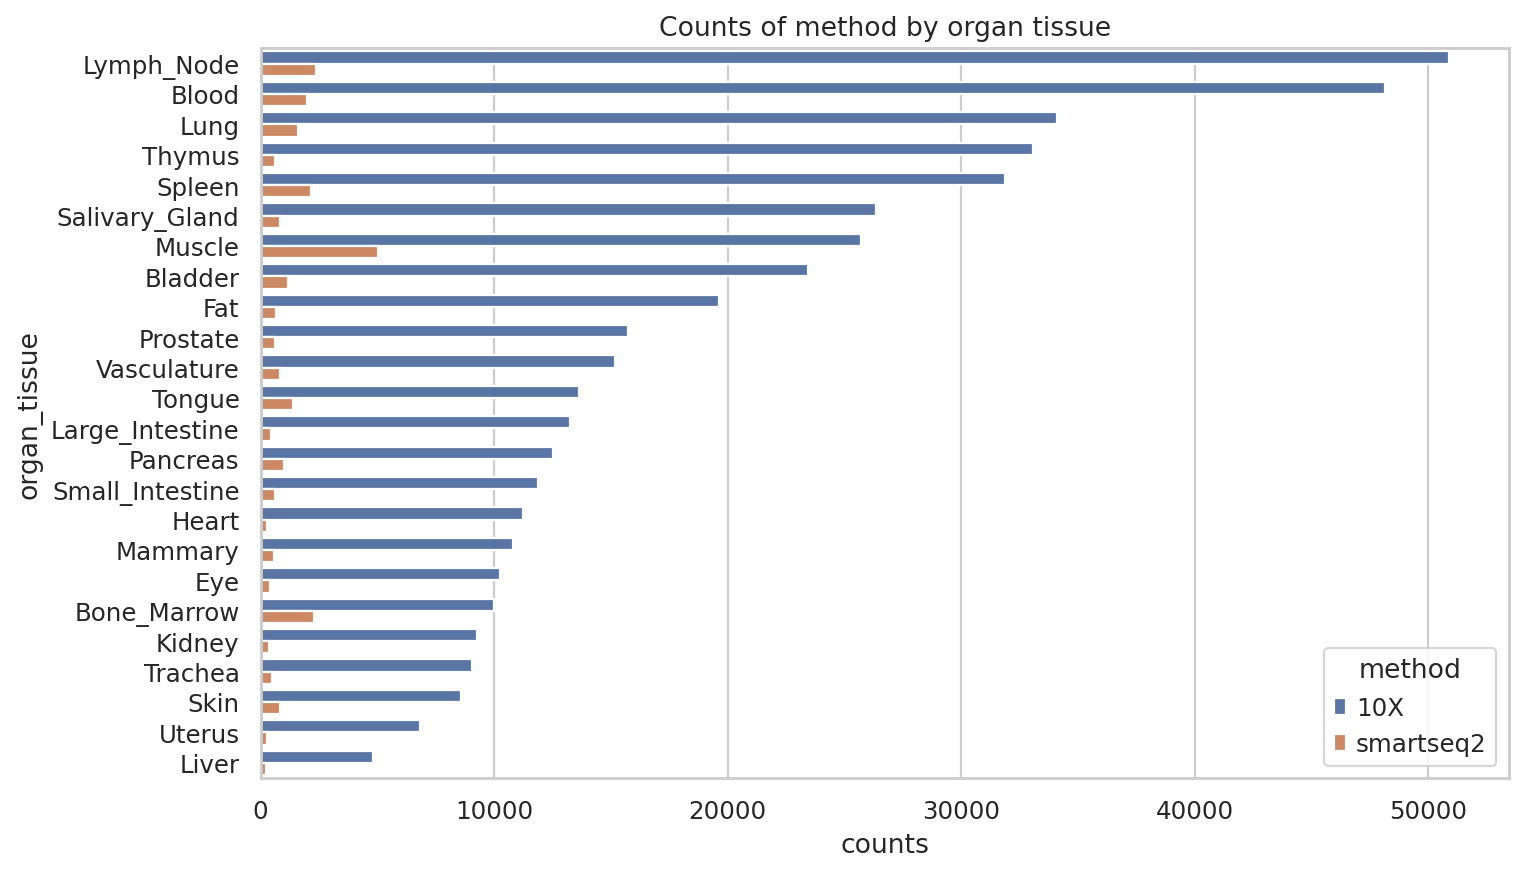

In [8]:
# make barplot of counts of method by organ tissue follow order_organs
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="counts", y="organ_tissue", hue="method", data=method_counts, order=order_organs)
plt.title('Counts of method by organ tissue')
plt.show()

In [9]:
# total number of cells by method
adata.obs.groupby(['method']).size().reset_index(name='counts')

/scratch/ipykernel_4489/2334889813.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(['method']).size().reset_index(name='counts')


,method,counts
0,10X,456101
1,smartseq2,27051


In [46]:
adata.obs.cell_ontology_class.value_counts()

cell_ontology_class
macrophage                               1597
mesenchymal stem cell                    1423
cd8-positive, alpha-beta t cell          1192
cd4-positive, alpha-beta t cell          1181
memory b cell                            1111
                                         ... 
mature conventional dendritic cell          1
ionocyte                                    1
retinal blood vessel endothelial cell       1
retinal bipolar neuron                      1
radial glial cell                           1
Name: count, Length: 133, dtype: int64

In [10]:
# remove ".14" or anything after period for every value in gene ids ENSG00000023902.14 
adata.var.index = adata.var.index.str.split('.').str[0]

### Filter just SS2 data now...

In [13]:
# Filter adata object to just ss2 data and muscle tissue 
adata = adata[adata.obs["method"] == "smartseq2"].copy()

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [15]:
adata.obs.groupby("organ_tissue").size().sort_values(ascending=False)

/scratch/ipykernel_4489/3071496183.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("organ_tissue").size().sort_values(ascending=False)


organ_tissue
Muscle             5043
Lymph_Node         2384
Bone_Marrow        2290
Spleen             2148
Blood              1977
Lung               1590
Tongue             1391
Bladder            1161
Pancreas            996
Vasculature         847
Skin                844
Salivary_Gland      832
Fat                 651
Prostate            633
Small_Intestine     606
Thymus              599
Mammary             580
Trachea             474
Large_Intestine     442
Eye                 417
Kidney              370
Uterus              286
Heart               277
Liver               213
dtype: int64

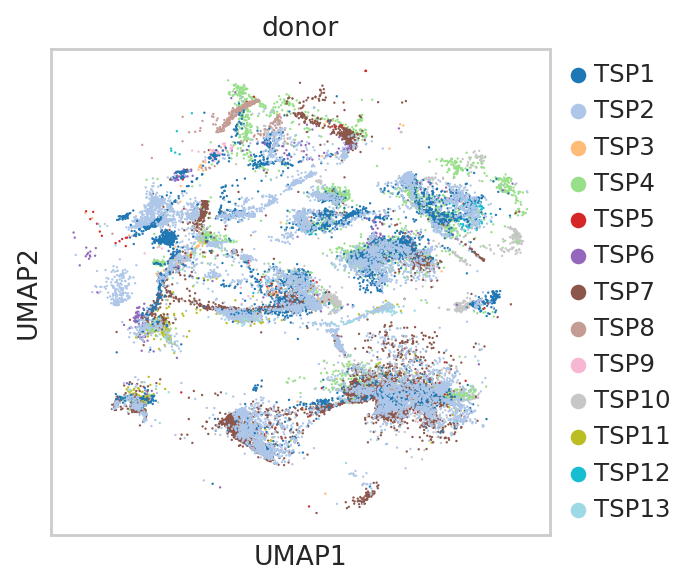

In [18]:
# use values in adata.obsm to plot the UMAP
sc.pl.umap(adata, color=["donor"], palette="tab20", ncols=2)

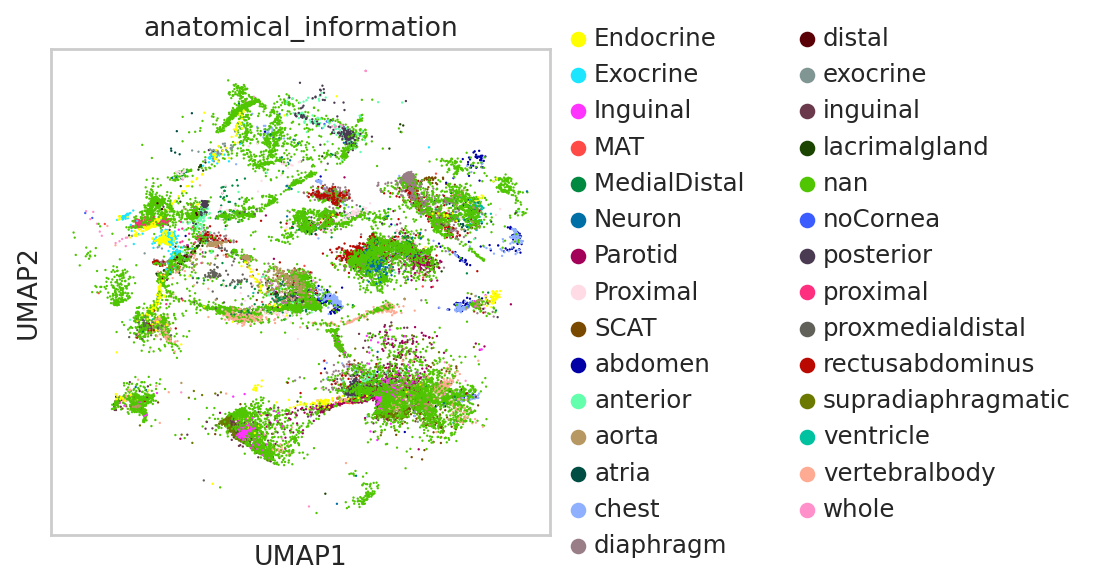

In [19]:
sc.pl.umap(adata, color=["anatomical_information"])

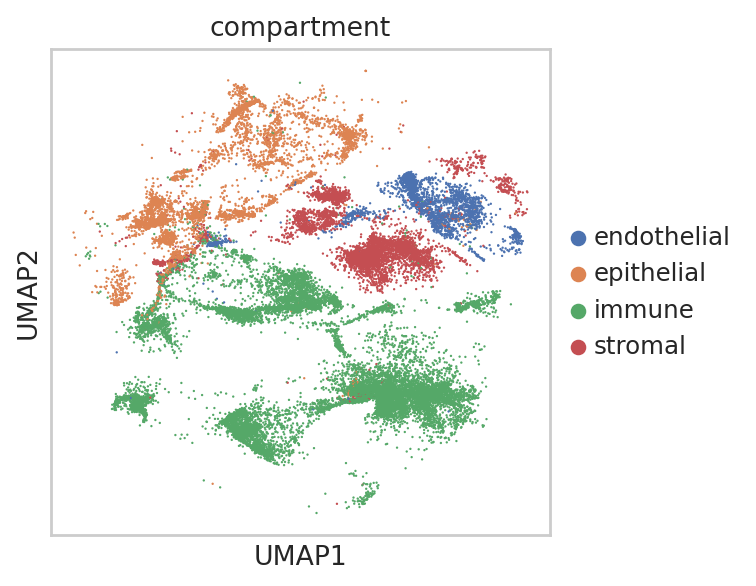

In [21]:
sc.pl.umap(adata, color = "compartment")

In [22]:
adata.obs.groupby(["cell_ontology_class", "compartment"]).size().sort_values(ascending=False)

/scratch/ipykernel_4489/1681375125.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(["cell_ontology_class", "compartment"]).size().sort_values(ascending=False)


cell_ontology_class              compartment
macrophage                       immune         1597
mesenchymal stem cell            stromal        1423
cd8-positive, alpha-beta t cell  immune         1192
cd4-positive, alpha-beta t cell  immune         1181
memory b cell                    immune         1111
                                                ... 
hematopoietic stem cell          epithelial        0
                                 endothelial       0
granulocyte                      stromal           0
                                 epithelial        0
vein endothelial cell            stromal           0
Length: 532, dtype: int64

In [52]:
nums = adata.obs.groupby(["cell_ontology_class", "organ_tissue"]).size().sort_values(ascending=False)
# keep only values greater than 0
nums = nums[nums > 0]
nums[0:20]

/scratch/ipykernel_4489/911070189.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nums = adata.obs.groupby(["cell_ontology_class", "organ_tissue"]).size().sort_values(ascending=False)


cell_ontology_class                     organ_tissue   
mesenchymal stem cell                   Muscle             1423
basal cell                              Tongue              804
endothelial cell of vascular tree       Muscle              735
skeletal muscle satellite stem cell     Muscle              611
memory b cell                           Spleen              544
monocyte                                Blood               537
pancreatic acinar cell                  Pancreas            536
innate lymphoid cell                    Lymph_Node          514
macrophage                              Muscle              508
immune cell                             Tongue              495
cd4-positive, alpha-beta t cell         Blood               493
cd8-positive, alpha-beta t cell         Muscle              488
mature enterocyte                       Small_Intestine     443
b cell                                  Lymph_Node          441
capillary endothelial cell              Muscle  

In [53]:
# subset nums to where cell_ontology_class is "macrophage"
nums[nums.index.get_level_values("cell_ontology_class") == "macrophage"]

cell_ontology_class  organ_tissue
macrophage           Muscle          508
                     Vasculature     247
                     Bladder         236
                     Skin            190
                     Lung            126
                     Fat              90
                     Liver            74
                     Heart            26
                     Spleen           23
                     Uterus           18
                     Thymus           18
                     Mammary          13
                     Trachea          10
                     Eye               8
                     Kidney            6
                     Lymph_Node        3
                     Bone_Marrow       1
dtype: int64

In [23]:
# sumamrize number of samples across donors and organs and filter out zero entries 
donors_summ = adata.obs.groupby(["donor", "organ_tissue"]).size().unstack().fillna(0)
# remove rows that have all zeros
donors_summ = donors_summ.loc[(donors_summ != 0).any(axis=1)]

/scratch/ipykernel_4489/1888885378.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  donors_summ = adata.obs.groupby(["donor", "organ_tissue"]).size().unstack().fillna(0)


In [25]:
ss2 = adata.obs.copy()
ss2["bam_file_name"] = ss2.index

In [26]:
# Assuming 'ss2' is your DataFrame
ss2.loc[ss2["donor"] == "TSP1", "donor_id"] = "Pilot1"
ss2.loc[ss2["donor"] == "TSP2", "donor_id"] = "Pilot2"
ss2.loc[ss2["donor"] == "TSP3", "donor_id"] = "Pilot3"
ss2.loc[ss2["donor"] == "TSP4", "donor_id"] = "Pilot4"
ss2.loc[ss2["donor"] == "TSP5", "donor_id"] = "Pilot5"
ss2.loc[ss2["donor"] == "TSP6", "donor_id"] = "Pilot6"
ss2.loc[ss2["donor"] == "TSP7", "donor_id"] = "Pilot7"
ss2.loc[ss2["donor"] == "TSP8", "donor_id"] = "Pilot8"
ss2.loc[ss2["donor"] == "TSP9", "donor_id"] = "Pilot9"
ss2.loc[ss2["donor"] == "TSP10", "donor_id"] = "Pilot10"
ss2.loc[ss2["donor"] == "TSP11", "donor_id"] = "Pilot11"
ss2.loc[ss2["donor"] == "TSP12", "donor_id"] = "Pilot12"
ss2.loc[ss2["donor"] == "TSP13", "donor_id"] = "Pilot13"
ss2.loc[ss2["donor"] == "TSP14", "donor_id"] = "Pilot14"
ss2.loc[ss2["donor"] == "TSP15", "donor_id"] = "Pilot15"

In [27]:
ss2[ss2["bam_file_name"] == "TSP2_LymphNode_Inguinal_SS2_B113694_B133052_ImmuneLinNeg_I10_S202"]

,organ_tissue,method,donor,anatomical_information,n_counts_UMIs,n_genes,cell_ontology_class,free_annotation,manually_annotated,compartment,gender,bam_file_name,donor_id
TSP2_LymphNode_Inguinal_SS2_B113694_B133052_ImmuneLinNeg_I10_S202,Lymph_Node,smartseq2,TSP2,Inguinal,327571.0,2108,"cd4-positive, alpha-beta memory t cell","cd4-positive, alpha-beta memory t cell",True,immune,female,TSP2_LymphNode_Inguinal_SS2_B113694_B133052_Im...,Pilot2


In [28]:
ss2[ss2["organ_tissue"] == "Muscle"].donor.unique()

['TSP4', 'TSP1', 'TSP2']
Categories (13, object): ['TSP1', 'TSP2', 'TSP3', 'TSP4', ..., 'TSP10', 'TSP11', 'TSP12', 'TSP13']

In [29]:
# write SS2 to file saved as "tabula_sapiens_ss2_metadata.csv"
# ss2.to_csv("/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/tabula_sapiens_ss2_metadata.csv", index=False)

# save ss2 file as text file for saving BAM files 
# ss2_short = ss2[["donor", "organ_tissue", "bam_file_name", "donor_id"]]
# ss2_short.to_csv("/commons/projects/CZI-tabula-sapiens/SS2_data_processing/ss2_samples.txt", sep="\t", index=False, header=False)

In [43]:
adata

AnnData object with n_obs × n_vars = 27051 × 58870
    obs: 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender'
    var: 'gene_symbol', 'feature_type', 'ensemblid', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: '_scvi', '_training_mode', 'dendrogram_cell_type_tissue', 'dendrogram_computational_compartment_assignment', 'dendrogram_consensus_prediction', 'dendrogram_tissue_cell_type', 'donor_colors', 'donor_method_colors', 'hvg', 'method_colors', 'neighbors', 'organ_tissue_colors', 'sex_colors', 'tissue_colors', 'umap', 'anatomical_information_colors', 'cell_ontology_class_colors', 'compartment_colors'
    obsm: 'X_pca', 'X_scvi', 'X_scvi_umap', 'X_umap'
    layers: 'decontXcounts', 'raw_counts'
    obsp: 'connectivities', 'distances'

In [ ]:
# subset adata to just the cells in ss2 
adata.obsm["X_umap"]

# turn adata.obsm["X_umap"] into dataframe 
umap = pd.DataFrame(adata.obsm["X_umap"])
umap["cell_id"] = adata.obs.index
umap.head()

In [ ]:
umap = umap[umap.cell_id.isin(ss2.index)]
umap.head()

In [ ]:
LN = ss2[ss2["organ_tissue"] == "Muscle"]
umap = umap[umap.cell_id.isin(LN.index)]
umap.head()

In [ ]:
# change umap columns to UMAP1, UMAP2
umap.columns = ['UMAP1', 'UMAP2', 'cell_id']

In [ ]:
ss2["cell_id"] = ss2.index 
# merge ss2 and umap 
umap = ss2.merge(umap)

In [ ]:
# assign unique colors to free_annotation column and use those to make scatterplot
annotations = umap['free_annotation'].unique()

# Then we generate a list of colors for these labels.
colors = plt.cm.tab20(np.linspace(0, 1, len(annotations)))

# Now we create a dictionary that maps annotations to colors.
annotation_to_color = dict(zip(annotations, colors))

# We apply this mapping to the 'free_annotation' column to get the actual color values.
umap['color'] = umap['free_annotation'].map(annotation_to_color)

umap

In [ ]:
umap.cell_ontology_class.value_counts().head(20)

In [ ]:
# Create a list of patches to use as handles in the legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=annotation_to_color[annotation], label=annotation) for annotation in annotations]

# plt scatter plot of umap1 vs umap2 and color by free_annotation
plt.figure(figsize=(7,7))
plt.scatter(umap["UMAP1"], umap["UMAP2"], c=umap["color"], cmap="tab20", alpha=0.5)
plt.title("Lymph Node")
plt.show()

In [ ]:
plt.scatter(umap["UMAP1"], umap["UMAP2"], c=umap["color"], cmap="tab20", alpha=0.5)

In [ ]:
# magic incantation to help matplotlib work with our jupyter notebook
%matplotlib inline 

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

In [ ]:
plt.legend(handles=legend_handles, title='Annotations')


In [ ]:
adata

In [ ]:
# subset adata to just the cells in ss2 and muscle organ 
adata = adata[adata.obs.index.isin(ss2.index)]
adata = adata[adata.obs.index.isin(LN.index)]
adata

In [ ]:
sc.pl.highest_expr_genes(adata, n_top=20, )

In [ ]:
sc.pp.filter_cells(adata, min_genes=200) # remove cells that have less than 200 genes expressed
sc.pp.filter_genes(adata, min_cells=5) # remove genes that are expressed in less than 3 cells
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
# remove cells that have more than 5% mitochondrial genes
adata

In [ ]:
# With pp.calculate_qc_metrics, we can compute many metrics very efficiently.
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts'],
             jitter=0.4, multi_panel=True)

In [ ]:
print("Remove cells with very high values for total_counts, possible doublets")

print('Started with: \n', adata)
print_separator()
adata = adata[adata.obs.total_counts < 10000, :]
print('Finished with: \n', adata)

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

#sc.pl.highly_variable_genes(adata)

adata.raw = adata
adata = adata[:, adata.var.highly_variable]

#Regress out effects of total counts per cell and the percentage of mitochondrial genes expressed. Scale the data to unit variance.
sc.pp.regress_out(adata, ['total_counts'])

#Scale each gene to unit variance. Clip values exceeding standard deviation 10.
sc.pp.scale(adata, max_value=10)

In [ ]:
adata.obs.head()

In [ ]:
# remove these cell types from adata: endothelial cell of artery, erythrocyte, mesothelial cell             
adata = adata[~adata.obs["free_annotation"].isin(["endothelial cell of artery", "erythrocyte", "mesothelial cell"]), :]              

In [ ]:
print("The number of cells and genes going into PCA is: " + str(adata.shape))
sc.tl.pca(adata, svd_solver='arpack')

In [ ]:
sc.pl.pca(adata, color='cell_ontology_class')

In [ ]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.tl.leiden(adata)

In [ ]:
sc.pl.umap(adata, color=['leiden'])

In [ ]:
sc.pl.umap(adata, color=['cell_ontology_class'])

In [ ]:
# plot adata umap color by TSP by donor
# use colors grey, blue and red for TSP1, TSP2, TSP4
sc.pl.umap(adata, color=['donor'], palette=["grey", "blue", "red"])

In [ ]:
sc.pl.umap(adata, color=['anatomical_information'])

In [ ]:
# calculate total counts per cell across each donor 
adata.obs.groupby("donor").total_counts.sum()

In [ ]:
adata.obs